## Settings

In [1]:
import os, sys
import pandas as pd
from pathlib import Path
from dotenv import load_dotenv

sys.path.append(os.path.abspath('../../..'))
load_dotenv(os.path.join('../../..', '.env'))

os.environ['GRAPHRAG_API_KEY'] = os.environ.get('GEMINI_API_KEY', '')

QUESTION_TYPE = "comparative"          # local | global | multihop | comparative | negative
N_LIBROS      = 10
MAX_Q         = None
SHUFFLE       = False
RESULTS_DIR   = Path("./results")
RESULTS_DIR.mkdir(exist_ok=True)
DOMINIO = "cs"

In [2]:
DB_RAG = "../../../chroma_db_eval_traditional"
DB_RAGPlusPlus = "../../../chroma_db_RAGPlusPlus"
DB_LightRAG = "../../../lightrag_eval"
DB_PropertyRAG = ""
DB_MSGraphRAG = "../../../ms_graphrag_workspace"

In [3]:
from src.evaluation.experiment import run_local_experiment

PATH_PREGUNTAS = "./qa/comparativeQA.json"
PATH_RESULTADOS = "./results/"

/Volumes/Toni 1TB/MESIIA/TFM/TFM_Repositori/Code_TFM/venv/lib/python3.10/site-packages/google/api_core/_python_version_support.py:275: FutureWarning: You are using a Python version (3.10.20) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)
/Volumes/Toni 1TB/MESIIA/TFM/TFM_Repositori/Code_TFM/venv/lib/python3.10/site-packages/instructor/providers/gemini/client.py:6: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  import google.generativeai as genai


## Traditional RAG

In [4]:
from src.baselines.traditional_rag import TraditionalRAG

rag = TraditionalRAG(persist_directory=DB_RAG)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Cargando índice existente desde ../../../chroma_db_eval_traditional...


In [5]:
resultado = await run_local_experiment(
    rag_type="traditional",
    rag_object=rag,
    questions_path=PATH_PREGUNTAS,
    save_path=PATH_RESULTADOS,
    nombre_experimento="Test_Comparative_01"
)


🔍 Evaluando TRADITIONAL | Test_Comparative_01 | 20 preguntas
────────────────────────────────────────────────────────────
  [1/20] Compare the error handling approach in Java as described in Streib's b...
  [2/20] Both Celko's SQL book and the SQL Server book by Vieira discuss indexi...
  [3/20] Compare the target audience of Modern Optimization With R versus Machi...
  [4/20] Both the regular expressions book and the SQL books provide pattern ma...
  [5/20] Compare the use of lambda calculus in Dowek's theory book versus the u...
  [6/20] Compare how the Java book and the VBA book handle object-oriented prog...
  [7/20] Both the statistics book and the optimization book use probabilistic m...
  [8/20] Compare the abstraction level of the Linux Kernel Networking book vers...
  [9/20] Compare SQL Server's transaction isolation levels described by Vieira ...
  [10/20] Both the regular expressions book and the programming languages theory...
  [11/20] Compare the optimization strategies 

## RAG++

In [6]:
from src.baselines.advanced_rag import AdvancedRAG

rag_advanced = AdvancedRAG(persist_directory=DB_RAGPlusPlus)
rag_advanced.load_existing_index() 

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


   Docs recuperados de Chroma: 11824
   _all_docs construidos: 11824


In [7]:
resultado = await run_local_experiment(
    rag_type="advanced",
    rag_object=rag_advanced,
    questions_path=PATH_PREGUNTAS,
    save_path=PATH_RESULTADOS,
    nombre_experimento="Test_Comparative_01"
)


🔍 Evaluando ADVANCED | Test_Comparative_01 | 20 preguntas
────────────────────────────────────────────────────────────
  [1/20] Compare the error handling approach in Java as described in Streib's b...
  [2/20] Both Celko's SQL book and the SQL Server book by Vieira discuss indexi...
  [3/20] Compare the target audience of Modern Optimization With R versus Machi...
  [4/20] Both the regular expressions book and the SQL books provide pattern ma...
  [5/20] Compare the use of lambda calculus in Dowek's theory book versus the u...
  [6/20] Compare how the Java book and the VBA book handle object-oriented prog...
  [7/20] Both the statistics book and the optimization book use probabilistic m...
  [8/20] Compare the abstraction level of the Linux Kernel Networking book vers...
  [9/20] Compare SQL Server's transaction isolation levels described by Vieira ...
  [10/20] Both the regular expressions book and the programming languages theory...
  [11/20] Compare the optimization strategies in 

## LightRAG

In [8]:
from src.baselines.lightrag_rag import build_lightrag

rag_light, tracker = await build_lightrag(
    workspace_dir=DB_LightRAG,
    clean=False,
)

INFO: [] Loaded graph from ../../../lightrag_eval/graph_chunk_entity_relation.graphml with 54773 nodes, 72142 edges
INFO:nano-vectordb:Load (54773, 3072) data
INFO:nano-vectordb:Init {'embedding_dim': 3072, 'metric': 'cosine', 'storage_file': '../../../lightrag_eval/vdb_entities.json'} 54773 data
INFO:nano-vectordb:Load (72142, 3072) data
INFO:nano-vectordb:Init {'embedding_dim': 3072, 'metric': 'cosine', 'storage_file': '../../../lightrag_eval/vdb_relationships.json'} 72142 data
INFO:nano-vectordb:Load (3712, 3072) data
INFO:nano-vectordb:Init {'embedding_dim': 3072, 'metric': 'cosine', 'storage_file': '../../../lightrag_eval/vdb_chunks.json'} 3712 data
INFO: [] Process 16417 KV load full_docs with 10 records
INFO: [] Process 16417 KV load text_chunks with 3712 records
INFO: [] Process 16417 KV load full_entities with 10 records
INFO: [] Process 16417 KV load full_relations with 10 records
INFO: [] Process 16417 KV load entity_chunks with 54773 records
INFO: [] Process 16417 KV load r

✅ LightRAG inicializado en: ../../../lightrag_eval
   max_async=12 | max_retries=10 | modelo=gemini-2.5-flash-lite
   chunk_size=600 | gleaning=0


In [9]:
resultado = await run_local_experiment(
    rag_type="lightrag",
    rag_object=rag_light,
    questions_path=PATH_PREGUNTAS,
    save_path=PATH_RESULTADOS,
    nombre_experimento="Test_Comparative_01"
)

INFO: LLM func: 12 new workers initialized (Timeouts: Func: 180s, Worker: 360s, Health Check: 375s)



🔍 Evaluando LIGHTRAG | Test_Comparative_01 | 20 preguntas
────────────────────────────────────────────────────────────
  [1/20] Compare the error handling approach in Java as described in Streib's b...


INFO:  == LLM cache == saving: hybrid:keywords:c436999cdcd41a065bc461d576d35df8
INFO: Embedding func: 8 new workers initialized (Timeouts: Func: 30s, Worker: 60s, Health Check: 75s)
INFO: Query nodes: Java, Streib's book, VBA, Mansfield's book, Exception handling, Error codes (top_k:40, cosine:0.2)
INFO: Local query: 40 entites, 240 relations
INFO: Query edges: Error handling, Type safety, Programming languages, Comparative analysis (top_k:40, cosine:0.2)
INFO: Global query: 57 entites, 40 relations
INFO: Raw search results: 96 entities, 275 relations, 0 vector chunks
INFO: After truncation: 56 entities, 206 relations
INFO: Selecting 140 from 481 entity-related chunks by vector similarity
INFO: Find 56 additional chunks in 49 relations (deduplicated 31)
INFO: Selecting 56 from 56 relation-related chunks by vector similarity
INFO: Round-robin merged chunks: 196 -> 196 (deduplicated 0)
INFO: Final context: 56 entities, 206 relations, 20 chunks
INFO: Final chunks S+F/O: E5/1 R1/1 E1/2 R1/

  [2/20] Both Celko's SQL book and the SQL Server book by Vieira discuss indexi...


INFO:  == LLM cache == saving: hybrid:keywords:3bd82436b356647f3545f0181d3c78c2
INFO: Query nodes: Celko's SQL book, SQL Server book, Vieira, Indexing (top_k:40, cosine:0.2)
INFO: Local query: 40 entites, 112 relations
INFO: Query edges: Indexing approaches, Philosophical differences, Practical differences (top_k:40, cosine:0.2)
INFO: Global query: 58 entites, 40 relations
INFO: Raw search results: 97 entities, 150 relations, 0 vector chunks
INFO: After truncation: 57 entities, 150 relations
INFO: Selecting 142 from 548 entity-related chunks by vector similarity
INFO: Find 21 additional chunks in 20 relations (deduplicated 39)
INFO: Selecting 21 from 21 relation-related chunks by vector similarity
INFO: Round-robin merged chunks: 163 -> 163 (deduplicated 0)
INFO: Final context: 57 entities, 150 relations, 20 chunks
INFO: Final chunks S+F/O: E4/1 R1/1 E2/2 R15/2 E1/3 R1/3 E2/4 R1/4 E2/5 R1/5 E2/6 R1/6 E2/7 R1/7 E3/8 R2/8 E4/9 R1/9 E2/10 R1/10
INFO:  == LLM cache == saving: hybrid:query:

...

  RAGAS [7/20] Both the statistics book and the optimization book...


INFO:openai._base_client:Retrying request to /chat/completions in 0.376653 seconds


  RAGAS [8/20] Compare the abstraction level of the Linux Kernel ...
  RAGAS [9/20] Compare SQL Server's transaction isolation levels ...
  RAGAS [10/20] Both the regular expressions book and the programm...
  RAGAS [11/20] Compare the optimization strategies in Modern Opti...
  RAGAS [12/20] Both the Java book and the programming languages t...


INFO:openai._base_client:Retrying request to /chat/completions in 0.420141 seconds


  RAGAS [13/20] Compare the scalability of the optimization algori...
  RAGAS [14/20] Both Vieira's SQL Server book and Rosen's Linux Ke...
  RAGAS [15/20] Compare the use of recursion in Dowek's programmin...
  RAGAS [16/20] Both the statistics book and the machine learning ...
  RAGAS [17/20] Compare the naming convention philosophies of Celk...
  RAGAS [18/20] Both the VBA book and the Spark book automate repe...
  RAGAS [19/20] Compare how the Java book and the SQL book approac...
  RAGAS [20/20] Both the regular expressions book and the SQL book...

  💰 Tokens RAGAS:
     Total  : 194,791  (prompt: 166,806 | completion: 27,985)
     TPM    : 33,376 tokens/min
     RPM    : 24 requests/min  (140 requests en 5.84 min)
💾 Guardado en: ./results/lightrag_Test_Comparative_01_2026-05-02.json


## Property RAG

## MS_GraphRAG

In [10]:
from src.baselines.msgraphrag_rag import MSGraphRAG

ms_graph = MSGraphRAG(workspace_dir=DB_MSGraphRAG)
ms_graph.load()

📂 Cargando índice MS-GraphRAG...
   ✅ Entidades    : 31,159
   ✅ Relaciones   : 42,358
   ✅ Comunidades  : 4,612
   ✅ Reports      : 4,603
   ✅ Text units   : 1,867


In [11]:
resultado = await run_local_experiment(
    rag_type="msgraphrag_local",
    rag_object=ms_graph,
    questions_path=PATH_PREGUNTAS,
    save_path=PATH_RESULTADOS,
    nombre_experimento="Test_Comparative_01"
)


🔍 Evaluando MSGRAPHRAG_LOCAL | Test_Comparative_01 | 20 preguntas
────────────────────────────────────────────────────────────
  [1/20] Compare the error handling approach in Java as described in Streib's b...


12:14:52 - LiteLLM:INFO: utils.py:1307 - Wrapper: Completed Call, calling success_handler
INFO:LiteLLM:Wrapper: Completed Call, calling success_handler
12:14:52 - LiteLLM:INFO: utils.py:3427 - 
LiteLLM completion() model= gemini-2.5-flash-lite; provider = gemini
INFO:LiteLLM:
LiteLLM completion() model= gemini-2.5-flash-lite; provider = gemini


  [2/20] Both Celko's SQL book and the SQL Server book by Vieira discuss indexi...


12:14:56 - LiteLLM:INFO: utils.py:1307 - Wrapper: Completed Call, calling success_handler
INFO:LiteLLM:Wrapper: Completed Call, calling success_handler
12:14:56 - LiteLLM:INFO: utils.py:3427 - 
LiteLLM completion() model= gemini-2.5-flash-lite; provider = gemini
INFO:LiteLLM:
LiteLLM completion() model= gemini-2.5-flash-lite; provider = gemini


  [3/20] Compare the target audience of Modern Optimization With R versus Machi...


...

  RAGAS [10/20] Both the regular expressions book and the programm...


INFO:openai._base_client:Retrying request to /chat/completions in 0.476940 seconds
INFO:openai._base_client:Retrying request to /chat/completions in 0.398312 seconds


  RAGAS [11/20] Compare the optimization strategies in Modern Opti...
  RAGAS [12/20] Both the Java book and the programming languages t...
  RAGAS [13/20] Compare the scalability of the optimization algori...
  RAGAS [14/20] Both Vieira's SQL Server book and Rosen's Linux Ke...


INFO:openai._base_client:Retrying request to /chat/completions in 0.486821 seconds
INFO:openai._base_client:Retrying request to /chat/completions in 0.810482 seconds


  RAGAS [15/20] Compare the use of recursion in Dowek's programmin...
  RAGAS [16/20] Both the statistics book and the machine learning ...
  RAGAS [17/20] Compare the naming convention philosophies of Celk...
  RAGAS [18/20] Both the VBA book and the Spark book automate repe...
  RAGAS [19/20] Compare how the Java book and the SQL book approac...
  RAGAS [20/20] Both the regular expressions book and the SQL book...

  💰 Tokens RAGAS:
     Total  : 616,380  (prompt: 576,734 | completion: 39,646)
     TPM    : 99,887 tokens/min
     RPM    : 33 requests/min  (202 requests en 6.17 min)
💾 Guardado en: ./results/msgraphrag_local_Test_Comparative_01_2026-05-02.json


## Plots

✅ 4 RAGs cargados: ['traditional', 'advanced', 'lightrag', 'msgraphrag_local']


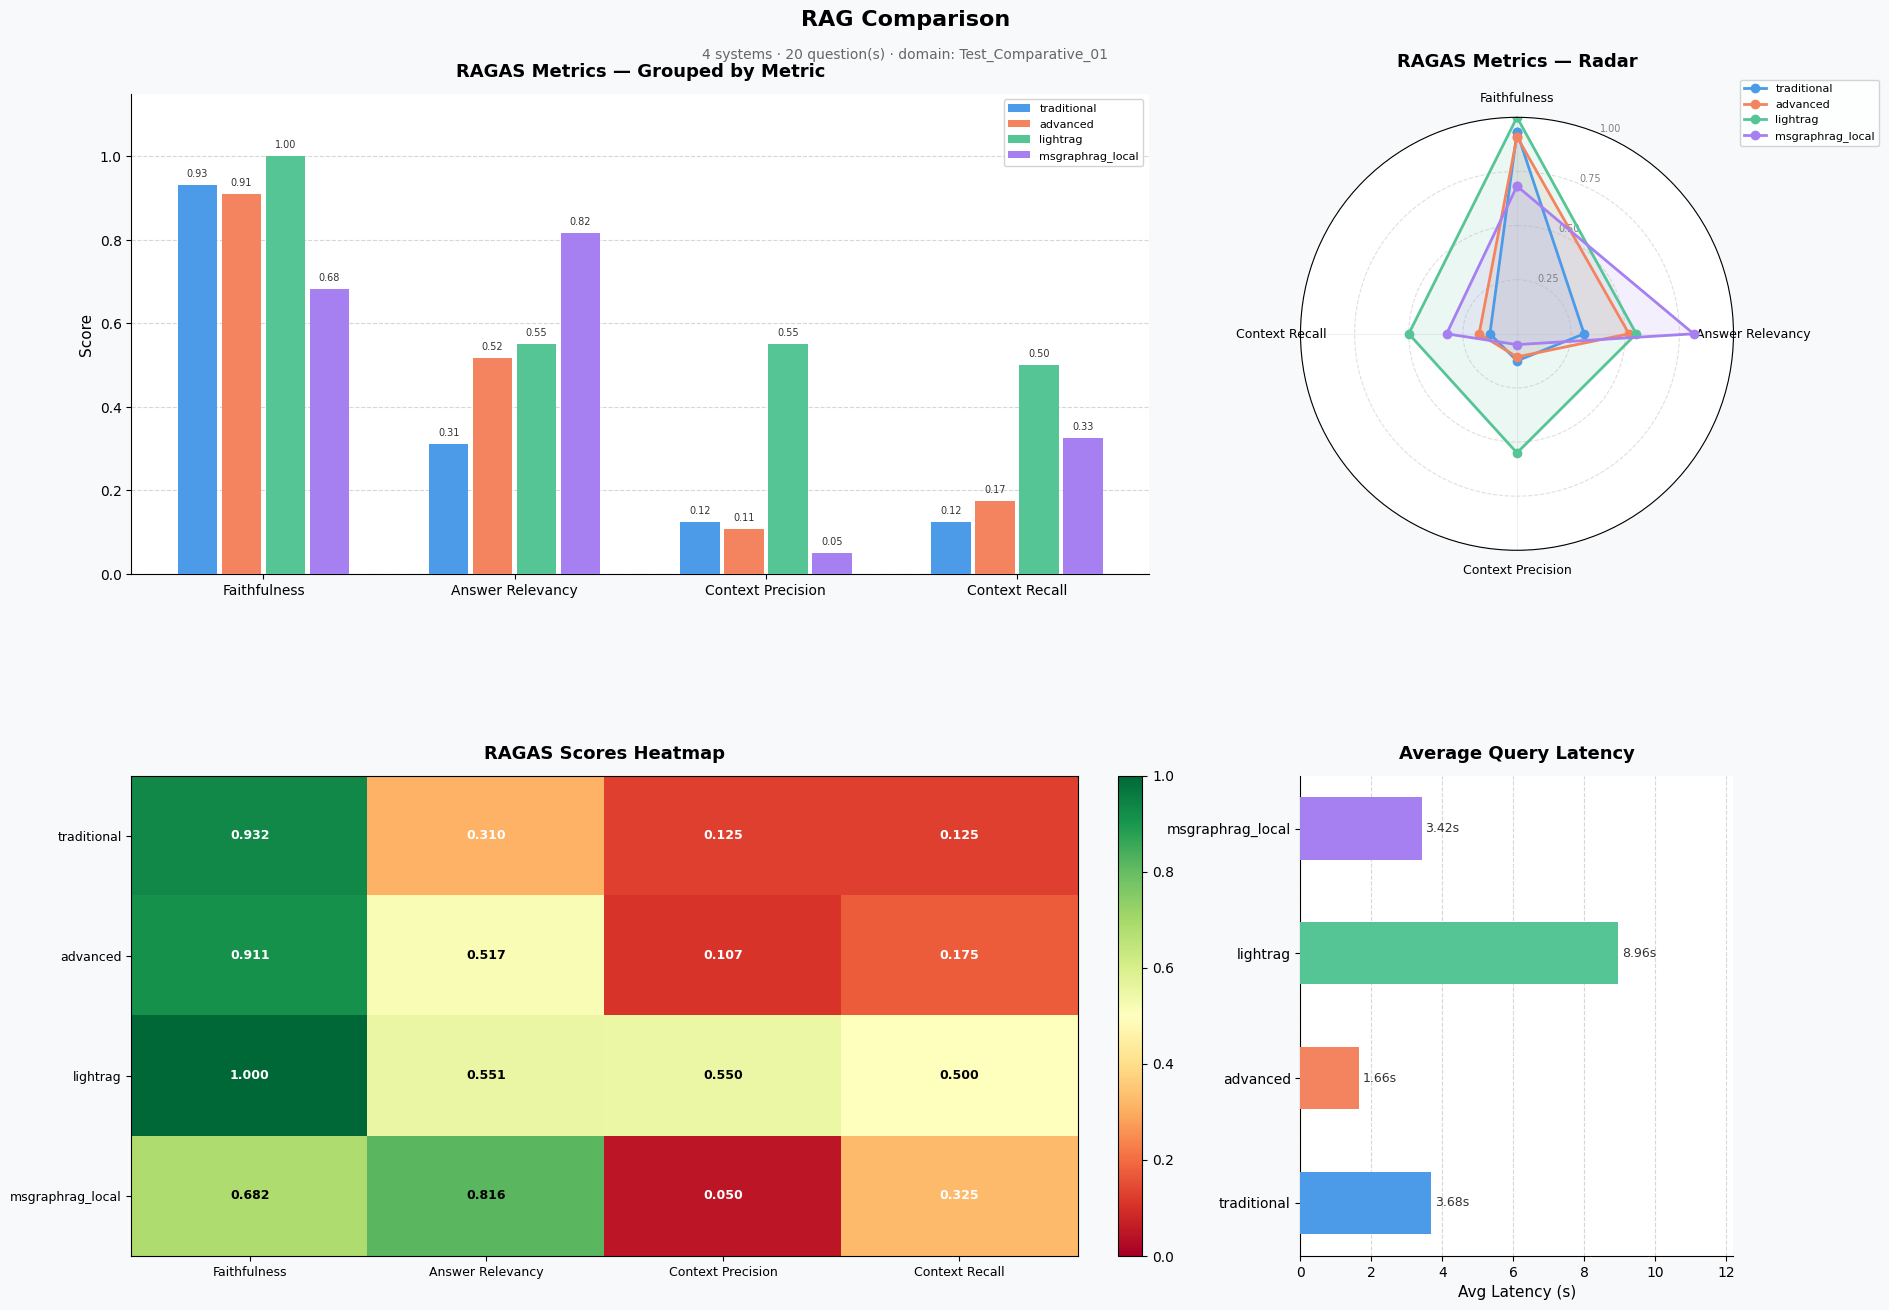

💾 Guardado en: plots/rag_comparison_comparison.png


PosixPath('plots/rag_comparison_comparison.png')

In [12]:
from src.plots.rag_visualizer import plot_rag_comparison

plot_rag_comparison(results_dir="./results", output_dir="./plots")